# ARTI403 - Image Processing
## Lab 1: Basics of Programming with Python



### Step 0: Install packages and download the sample images (run once)

In [1]:
%pip install -q opencv-python numpy pillow matplotlib

import os

images_dir = os.path.join(os.getcwd(), 'images')
os.makedirs(images_dir, exist_ok=True)

base_url = 'https://raw.githubusercontent.com/mohammadimtiazz/standard-test-images-for-Image-Processing/master/standard_test_images'
files = ['cameraman.tif', 'lena_gray_256.tif']

for f in files:
    dest = os.path.join(images_dir, f)
    url = f'{base_url}/{f}'
    # -L follows redirects, -o sets the output path, -s keeps it quiet
    !curl -L -s -o "{dest}" "{url}"
    size = os.path.getsize(dest) if os.path.exists(dest) else 0
    print(f'{f}: {"OK" if size > 0 else "FAILED"} ({size} bytes) -> {dest}')

Note: you may need to restart the kernel to use updated packages.
cameraman.tif: OK (262750 bytes) -> d:\download\images\cameraman.tif
lena_gray_256.tif: OK (65798 bytes) -> d:\download\images\lena_gray_256.tif


## Task #2: Loading and Visualizing Images

### a. Loading/reading an image using OpenCV

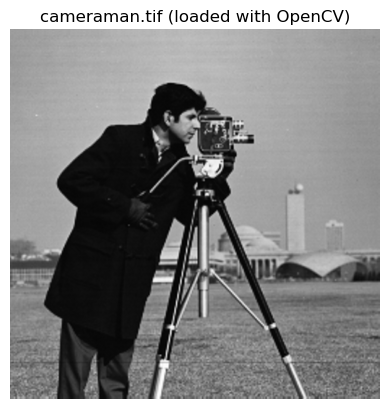

In [2]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread(os.path.join('images', 'cameraman.tif'))  # Load the image data into a NumPy array

plt.imshow(img)
plt.title('cameraman.tif (loaded with OpenCV)')
plt.axis('off')
plt.show()

### b. Loading/reading an image using PIL

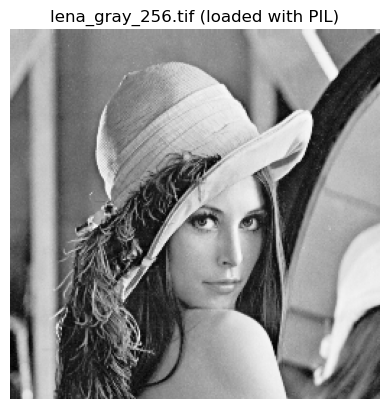

In [3]:
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.cm as cm

img2 = Image.open(os.path.join('images', 'lena_gray_256.tif'))  # load image into a PIL Image object

plt.imshow(img2, cmap=cm.Greys_r)
plt.title('lena_gray_256.tif (loaded with PIL)')
plt.axis('off')
plt.show()

## Task #3: Image Storing

### a. Saving image to disk using OpenCV

In [4]:
cv2.imwrite('new_image.jpg', img)
print('Saved new_image.jpg using OpenCV')

Saved new_image.jpg using OpenCV


### b. Saving an image to disk using PIL

In [5]:
img2.save('new_image2.jpg')
print('Saved new_image2.jpg using PIL')

Saved new_image2.jpg using PIL


## Task #4: Display Image as an Array

In [6]:
print(img.shape)  # Note: img loaded using OpenCV is a NumPy array
print(img)

(512, 512, 3)
[[[156 156 156]
  [157 157 157]
  [160 160 160]
  ...
  [152 152 152]
  [152 152 152]
  [152 152 152]]

 [[156 156 156]
  [157 157 157]
  [159 159 159]
  ...
  [152 152 152]
  [152 152 152]
  [152 152 152]]

 [[158 158 158]
  [157 157 157]
  [156 156 156]
  ...
  [152 152 152]
  [152 152 152]
  [152 152 152]]

 ...

 [[121 121 121]
  [123 123 123]
  [126 126 126]
  ...
  [121 121 121]
  [113 113 113]
  [111 111 111]]

 [[121 121 121]
  [123 123 123]
  [126 126 126]
  ...
  [121 121 121]
  [113 113 113]
  [111 111 111]]

 [[121 121 121]
  [123 123 123]
  [126 126 126]
  ...
  [121 121 121]
  [113 113 113]
  [111 111 111]]]


In [7]:
import numpy as np

# Convert the PIL image to a NumPy array
img_array = np.array(img2)

# Print the array
print(img_array.shape)
print(img_array)

(256, 256)
[[162 162 162 ... 168 171 155]
 [162 162 162 ... 168 171 155]
 [162 162 162 ... 168 171 155]
 ...
 [ 48  57  54 ...  75  97  88]
 [ 46  50  52 ...  89 100  98]
 [ 44  55  54 ...  97 100 105]]


## 4. Assessment: Operations on the Array using NumPy
The manual states: *"The student will be asked to perform different operations on the array using the NumPy library."*

Below are common operations you may be asked to demonstrate.

### Basic array info

In [8]:
print('Shape :', img_array.shape)
print('Size  :', img_array.size)
print('Dtype :', img_array.dtype)
print('Ndim  :', img_array.ndim)

Shape : (256, 256)
Size  : 65536
Dtype : uint8
Ndim  : 2


### Indexing and slicing (crop the top-left 100x100 corner)

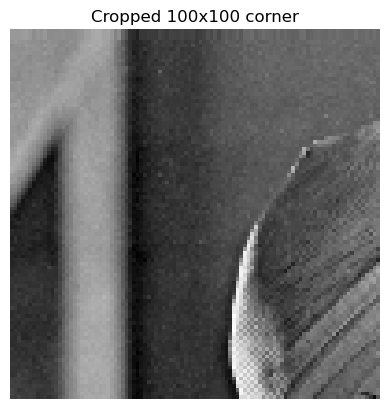

In [9]:
cropped = img_array[0:100, 0:100]
plt.imshow(cropped, cmap='gray')
plt.title('Cropped 100x100 corner')
plt.axis('off')
plt.show()

### Basic statistics

In [10]:
print('Min   :', img_array.min())
print('Max   :', img_array.max())
print('Mean  :', img_array.mean())
print('Std   :', img_array.std())

Min   : 26
Max   : 242
Mean  : 124.00845336914062
Std   : 47.83815266771587


### Flipping the image (vertically and horizontally)

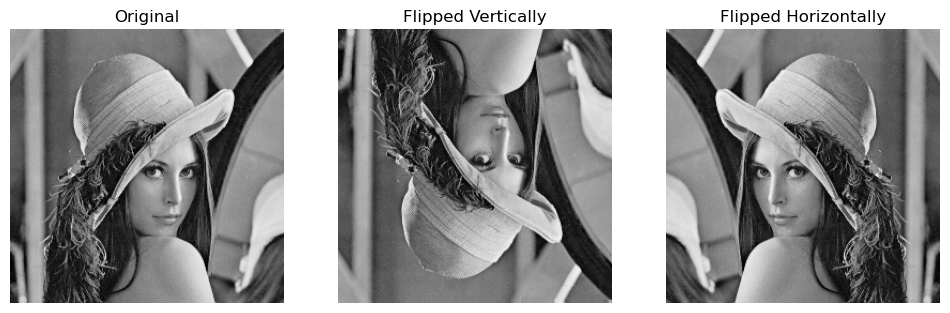

In [11]:
flipped_v = np.flipud(img_array)  # flip vertically
flipped_h = np.fliplr(img_array)  # flip horizontally

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(img_array, cmap='gray'); axes[0].set_title('Original'); axes[0].axis('off')
axes[1].imshow(flipped_v, cmap='gray'); axes[1].set_title('Flipped Vertically'); axes[1].axis('off')
axes[2].imshow(flipped_h, cmap='gray'); axes[2].set_title('Flipped Horizontally'); axes[2].axis('off')
plt.show()

### Inverting pixel intensities (negative image)

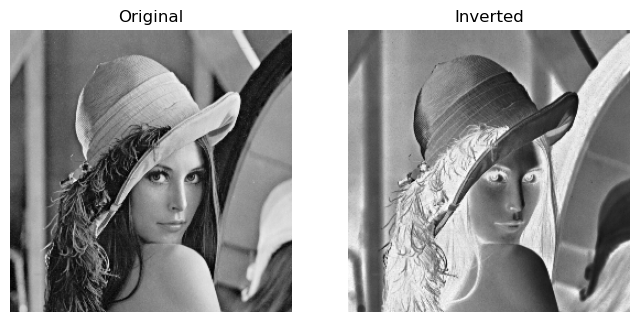

In [12]:
inverted = 255 - img_array

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(img_array, cmap='gray'); axes[0].set_title('Original'); axes[0].axis('off')
axes[1].imshow(inverted, cmap='gray'); axes[1].set_title('Inverted'); axes[1].axis('off')
plt.show()

### Simple thresholding (binarizing the image)

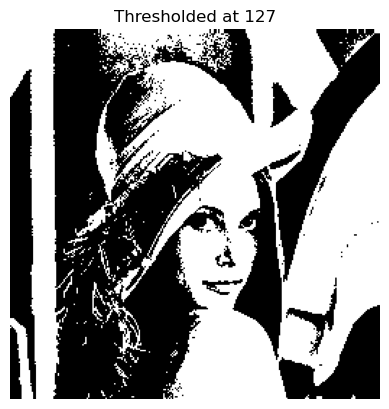

In [13]:
threshold = 127
binary = np.where(img_array > threshold, 255, 0).astype(np.uint8)

plt.imshow(binary, cmap='gray')
plt.title(f'Thresholded at {threshold}')
plt.axis('off')
plt.show()